In [3]:
import matplotlib.pyplot as plt
from natsort import realsorted
from event_analysis import plot_GR
import numpy as np
import os
plt.style.use('default')
fig, axs = plt.subplots(1,2,figsize=(14,7), sharey=True)
ax = axs[1]; ax2 = axs[0]

param_dict = {1:[2.5,0.001,100,100, 1.0],
                  2:[2.5,0.001,100,100, 2.5],
                  3:[2.5,0.001,100,100, 5.0],
                  4:[2.5,0.001,100,100, 10.0]}
events = []
params = param_dict[1]
eta = "\u03b7"
ax.text(s=f'(b)', x=-1, y= 10, size=20)
ax2.text(s=f'(a)', x=-1, y= 10, size=20)

b_values = []
b2_values = []
etas = []
dir2 = 'event_data_SRF/Damped Varied mesh size Alpha=1'
dir ='event_data_SRF/Damped Varied mesh size Alpha=3'
files = os.listdir(dir)
cmap1 = plt.get_cmap('viridis', len(os.listdir(dir))).colors[::-1]
cmap2 = plt.get_cmap('plasma', len(os.listdir(dir2))).colors[::-1]
b_range = {'0.25':(-5,2.5), '0.125':(-8,2.5),'0.0625':(-11,5),'0.04167':(-11.5,5), '0.083':(-9,2), '1':(-2,1)}
for n, filename in enumerate(realsorted(os.listdir(dir))):

    if filename == ".DS_Store":
        continue

    a = filename.split('=')[-1].removesuffix('.npy')


    events = np.load(dir+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]
    b = plot_GR(events,bin_size=0.333,title='',b_value=False, fig_ax=(fig,ax), label=f'a = {a}', cutoff_at_peak=True
                , element_size=float(a), linestyle='-', marker='', color=cmap1[n])
    b_values.append(b)

for n, filename in enumerate(realsorted(os.listdir(dir2))):

    if filename == ".DS_Store":
        continue

    a = filename.split('=')[-1].removesuffix('.npy')


    events = np.load(dir2+ '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]
    plot_GR(events,bin_size=0.333, title='',b_value=False, fig_ax=(fig,ax2), label=f'a = {a}', cutoff_at_peak=True
    ,b_range=(-8,-0), element_size=float(a), linestyle='-', marker='', color=cmap2[n])


ax.legend(loc='upper right')
ax.set_ylabel('')
ax2.legend(loc='upper right')
fig.tight_layout()


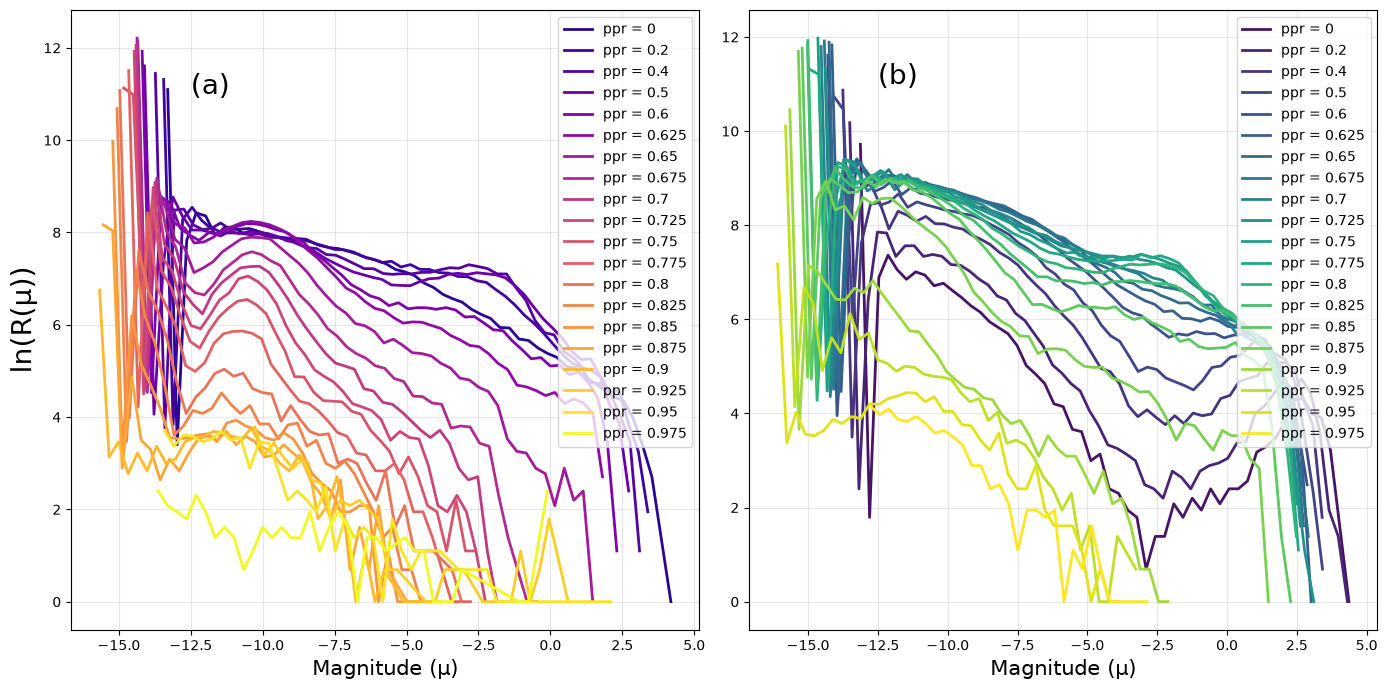

In [4]:
import matplotlib.pyplot as plt
from natsort import realsorted
from event_analysis import plot_GR
import numpy as np
import matplotlib.ticker as ticker
import os

plt.style.use('default')
fig, axs = plt.subplots(1,2, figsize=(14, 7))
ax = axs[1]; ax2 = axs[0]


eta = "\u03b7"
ax.text(s=f'(b)', x=-12.5, y=11, size=20)
ax2.text(s=f'(a)', x=-12.5, y=11, size=20)
b_values = []
b2_values = []
etas = []
dir2 = 'Constant pore pressure/Alpha 1 with nuleation'
dir = 'Constant pore pressure/Alpha 3 with nuleation'
cmap1 = plt.get_cmap('viridis', len(os.listdir(dir))).colors
cmap2 = plt.get_cmap('plasma', len(os.listdir(dir2))).colors
files = os.listdir(dir)
b_range = {'0.25': (-5, 2.5), '0.125': (-8, 2.5), '0.0625': (-11, 5), '0.04167': (-11.5, 5), '0.083': (-9, 2),
           '1': (-2, 1)}

for n, filename in enumerate(realsorted(os.listdir(dir)), start=0):

    if filename == ".DS_Store":
        continue
    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')

    events = np.load(dir + '/' + filename, allow_pickle=True)
    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]

    b = plot_GR(events, bin_size=0.33, title='', b_value=False, fig_ax=(fig, ax), label=f'ppr = {ppr}',
                cutoff_at_peak=True, cutoff=-25
                , element_size=float(a), linestyle='-', marker=None, color=cmap1[n], linewidth=2)
    b_values.append(b)

for n, filename in enumerate(realsorted(os.listdir(dir2)), start=0):

    if filename == ".DS_Store":
        continue

    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')

    events = np.load(dir2 + '/' + filename, allow_pickle=True)

    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]

    plot_GR(events, bin_size=0.33, title='', b_value=False, fig_ax=(fig, ax2), label=f'ppr = {ppr}',
            cutoff_at_peak=True, cutoff=-25
            , element_size=float(a), linestyle='-', marker=None, color=cmap2[n], linewidth=2)

ax.legend(loc='upper right')
ax2.legend(loc='upper right')
ax.set_ylabel('')
fig.tight_layout()
plt.show()



In [15]:
plt.style.use('default')

b_values_1 = []
etas = []
dir = 'Constant pore pressure/Alpha 1 with nuleation'

cmap1 = plt.get_cmap('viridis', len(os.listdir(dir))).colors
files = os.listdir(dir)
b_range = {'0': (-12.5, 2.5), '0.2': (-12.75, 2.5), '0.4': (-13, 1.83), '0.5': (-13.33, 1.5), '0.6': (-13.5, 1.25),
           '0.625': (-13.83, 1.5), '0.65': (-13.83, 1.25), '0.675': (-13.75, -2), '0.7': (-13.75, -2.18),
           '0.725': (-13.75, -2.5), '0.75': (-14, -2), '0.775': (-14, 1.5), '0.8': (-14.33, 1.5), '0.825': (-14.33, 1),
           '0.85': (-14.5, 1), '0.875': (-14.75, 1), '0.9': (-15.5, -3.5),  '0.925': (-15.5, -3.5),  '0.95': (-15.5, -3.5),  '0.975': (-15.5, -3.5)}

for n, filename in enumerate(realsorted(os.listdir(dir)), start=0):

    if filename == ".DS_Store":
        continue
    if filename == 'events_SRF_PPcont_alpha=1=_n=0.02_a=0.0625_ppr=0.975.npy':
        continue
    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')

    events = np.load(dir + '/' + filename, allow_pickle=True)
    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]
    max_mag = np.log(0.0625*events[:,2])
    b = plot_GR(events, bin_size=1, title=f'ppr = {ppr}', b_value=True, b_range=(-12.5,2.5), label=f'ppr = {ppr}',
                cutoff_at_peak=True, cutoff=-25
                , element_size=float(a), linestyle='-', marker=None, color=cmap1[n], linewidth=2)
    b_values_1.append(b)
    plt.clf()


import matplotlib.pyplot as plt
import matplotlib.collections as mcoll


cmap1 = plt.get_cmap('plasma', len(os.listdir(dir))).colors


pprs = [0, 0.2, 0.4, 0.5, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8, 0.825, 0.85, 0.875, 0.9]



c = pprs
points = np.array([pprs, np.abs(b_values_1)[:-2]]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc1 = mcoll.LineCollection(segments, cmap='plasma', array=c)
lc1.set_array(c)


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

...

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [16]:

b_values_3 = []

etas = []
dir = 'Constant pore pressure/Alpha 3 with nuleation'

cmap1 = plt.get_cmap('viridis', len(os.listdir(dir))).colors
files = os.listdir(dir)
b_range = {'0': (-12.25, -2.75), '0.2': (-12.75, -2), '0.4': (-13, -1.5), '0.5': (-13, -1), '0.6': (-13, 1.5),
           '0.625': (-13, 1.5), '0.65': (-13.25, 1.25), '0.675': (-13.5, 1.5), '0.7': (-13.5, 0),
           '0.725': (-13.75, 1.5), '0.75': (-13.75, 1), '0.775': (-14, 1.5), '0.8': (-14.33, 1.5), '0.825': (-14.33, 1),
           '0.85': (-14.33, 1), '0.875': (-14.5, 1), '0.9': (-14.83, -3.5), '0.925': (-15, -5), '0.95': (-11.33, -4.5), '0.975': (-13, -4)}

for n, filename in enumerate(realsorted(os.listdir(dir)), start=0):

    if filename == ".DS_Store":
        continue
    ppr = filename.split('=')[-1].removesuffix('.npy')
    a = filename.split('=')[-2].removesuffix('_ppr')

    events = np.load(dir + '/' + filename, allow_pickle=True)
    events = np.vstack(events)
    events = events[events[:, 0] > 5000]
    events = events[(events[:, 1] - events[:, 0]) < 75]

    b = plot_GR(events, bin_size=0.33, title=f'ppr = {ppr}', b_value=True, b_range=(-13, -1), label=f'ppr = {ppr}',
                cutoff_at_peak=False, cutoff=-30
                , element_size=float(a), linestyle='-', marker=None, color=cmap1[n], linewidth=2)
    b_values_3.append(b)
    plt.clf()

import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
cmap1 = plt.get_cmap('viridis', len(os.listdir(dir))).colors
pprs = [0, 0.2, 0.4, 0.5, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8, 0.825, 0.85, 0.875, 0.9,0.925,0.95,0.975]



c = pprs
points = np.array([pprs, np.abs(b_values_3)]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc2 = mcoll.LineCollection(segments, cmap='viridis', array=c)
lc2.set_array(c)


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

...

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

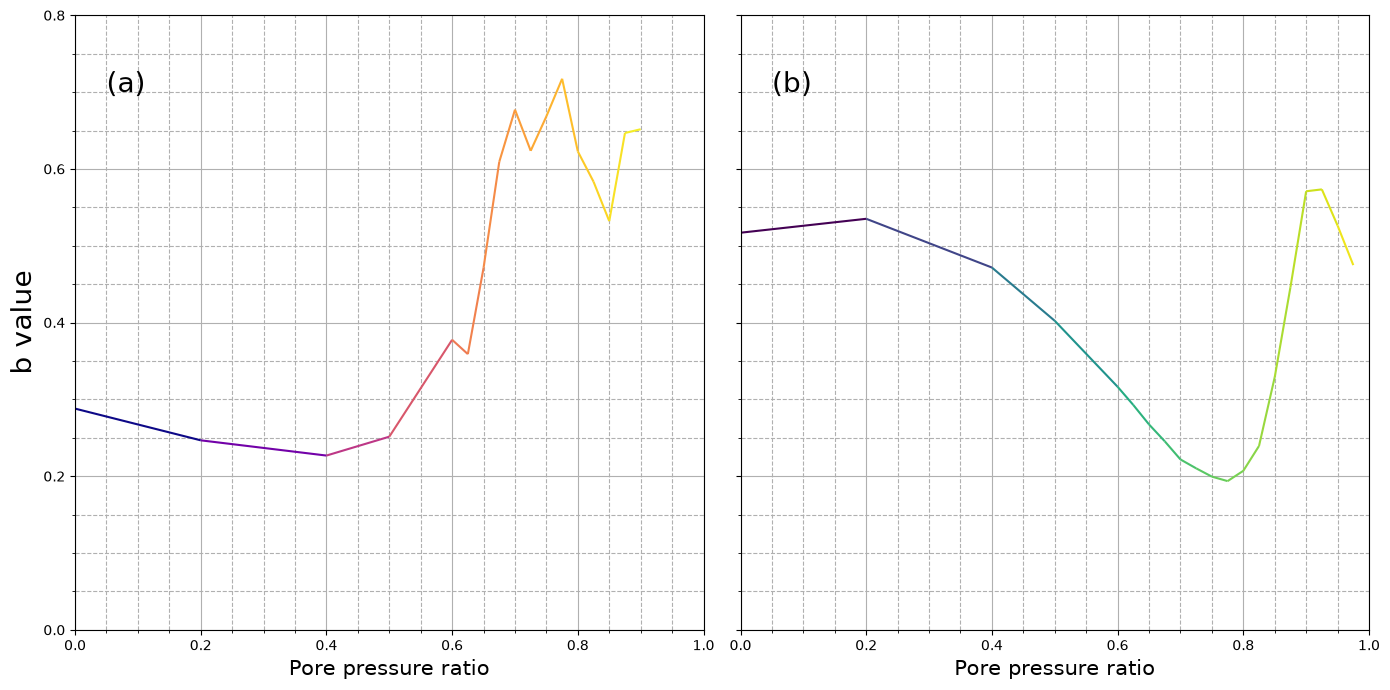

In [17]:
fig, axs = plt.subplots(1,2, figsize=(14, 7), sharey=True)
ax = axs[0]; ax2 = axs[1]
ax.grid(visible=True, which='major', linestyle='-')
ax2.grid(visible=True, which='major', linestyle='-')
ax.grid(visible=True, which='minor', linestyle='--')
ax2.grid(visible=True, which='minor', linestyle='--')
ax.set_ylabel('b value', size=20)
ax.set_xlabel('Pore pressure ratio', size=15) ; ax2.set_xlabel('Pore pressure ratio', size=15)
ax.minorticks_on()
ax2.minorticks_on()




ax2.text(s=f'(b)', x=0.05, y=0.7, size=20)
ax.text(s=f'(a)', x=0.05, y=0.7, size=20)
line1 = ax.add_collection(lc1)
line2 = ax2.add_collection(lc2)
ax.autoscale()

ax.set_xlim((0,1))
ax.set_ylim((0,0.8))
ax2.set_xlim((0,1))
ax2.set_ylim((0,0.8))
ax2.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
fig.tight_layout()


In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
from event_detection import detect_events_from_hist
plt.style.use('default')
fig, axs = plt.subplots(2,2, figsize=(14, 14), sharex=True, sharey=True, constrained_layout=True)
ax = axs[0,0]; ax2 = axs[0,1]; ax3 = axs[1,0]; ax4 = axs[1,1]
tl_data = np.load('for event plot/ppr_0/event_sample_SRF_10125.npy')
tr_data = np.load('for event plot/ppr_0.5/event_sample_SRF_10125.npy')
bl_data = np.load('for event plot/ppr_0.6/event_sample_SRF_10125.npy')
br_data = np.load('for event plot/ppr_0.75/event_sample_SRF_10125.npy')
a, tl_map = detect_events_from_hist(tl_data, 0.001, 10125, return_event_map=True)
a, tr_map = detect_events_from_hist(tr_data, 0.001, 10125, return_event_map=True)
a, bl_map = detect_events_from_hist(bl_data, 0.001, 10125, return_event_map=True)
a, br_map = detect_events_from_hist(br_data, 0.001, 10125, return_event_map=True)

n_steps = tl_map.shape[1]
times = 10125 + np.arange(n_steps) * 0.001
n_ticks = min(10, n_steps)
tick_indices = np.linspace(0, n_steps - 1, n_ticks, dtype=int)
ax.set_xticks(tick_indices)
ax.set_xticklabels([f'{times[i]:.0f}' for i in tick_indices])

custom_cmap = ListedColormap(['white', 'black'])
vmin, vmax = 0, 1
ax.imshow(tl_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax2.imshow(tr_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax3.imshow(bl_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax4.imshow(br_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)


ax.set_title('PPR = 0', size=20)
ax2.set_title('PPR = 0.5', size=20)
ax3.set_title('PPR = 0.6', size=20)
ax4.set_title('PPR = 0.75', size=20)
fig.text(0.5, -0.02, 'Time τ', ha='center',size=20)
fig.text(-0.02, 0.5, 'Element', va='center', rotation='vertical', size=20)


In [4]:
plt.style.use('default')
fig, axs = plt.subplots(2,2, figsize=(14, 14), sharex=True, sharey=True, constrained_layout=False)
fig.text(0.5, -0.1, 'Element', ha='center')
fig.text(-0.1, 0.5, 'Time τ', va='center', rotation='vertical')

ax = axs[0,0]; ax2 = axs[0,1]; ax3 = axs[1,0]; ax4 = axs[1,1]

custom_cmap = ListedColormap(['white', 'black'])
vmin, vmax = 0, 1
ax.imshow(tl_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax2.imshow(tr_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax3.imshow(bl_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)
ax4.imshow(br_map, aspect='auto', cmap=custom_cmap,
        interpolation='nearest', origin='lower', vmin=vmin, vmax=vmax)


ax.text(s=f'(a)', x=10130, y=2950, size=25, color='c')
ax2.text(s=f'(b)', x=10130, y=2950, size=25, color='c')
ax3.text(s=f'(c)', x=10130, y=2950, size=25, color='c')
ax4.text(s=f'(d)', x=10130, y=2950, size=25, color='c')

Text(10130, 2950, '(d)')

Error in callback <function _draw_all_if_interactive at 0x000001CA75E128D0> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 7.15 GiB for an array with shape (3200, 75001, 4) and data type float64

MemoryError: Unable to allocate 7.15 GiB for an array with shape (3200, 75001, 4) and data type float64

<Figure size 1400x1400 with 4 Axes>